**IMPORTING LIBRARIES**

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

**LOADING THE DATA**

In [2]:
Monero = pd.read_csv("/kaggle/input/cryptocurrencypricehistory/coin_Monero.csv")
Monero

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Monero,XMR,2014-05-22 23:59:59,2.188880,1.359090,1.589400,2.095580,1.329180e+05,1.855608e+06
1,2,Monero,XMR,2014-05-23 23:59:59,3.434370,2.051040,2.051040,2.963020,2.668520e+05,2.692180e+06
2,3,Monero,XMR,2014-05-24 23:59:59,4.014240,2.617780,2.920390,3.702450,2.480280e+05,3.456658e+06
3,4,Monero,XMR,2014-05-25 23:59:59,4.043030,2.803300,4.043030,3.138560,2.835450e+05,2.993339e+06
4,5,Monero,XMR,2014-05-26 23:59:59,3.762350,2.312020,3.218970,3.021860,2.201480e+05,2.946133e+06
...,...,...,...,...,...,...,...,...,...,...
2597,2598,Monero,XMR,2021-07-02 23:59:59,211.666077,199.608531,206.252403,211.345143,1.519434e+08,3.792466e+09
2598,2599,Monero,XMR,2021-07-03 23:59:59,216.327967,207.042192,211.458163,214.752778,1.364141e+08,3.853768e+09
2599,2600,Monero,XMR,2021-07-04 23:59:59,224.909012,213.023069,214.839958,219.841418,1.697858e+08,3.945232e+09
2600,2601,Monero,XMR,2021-07-05 23:59:59,220.354191,206.502607,219.961957,214.464993,1.709852e+08,3.848898e+09


In [3]:
Ethereum = pd.read_csv("/kaggle/input/cryptocurrencypricehistory/coin_Ethereum.csv")
Ethereum

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Ethereum,ETH,2015-08-08 23:59:59,2.798810,0.714725,2.793760,0.753325,6.741880e+05,4.548689e+07
1,2,Ethereum,ETH,2015-08-09 23:59:59,0.879810,0.629191,0.706136,0.701897,5.321700e+05,4.239957e+07
2,3,Ethereum,ETH,2015-08-10 23:59:59,0.729854,0.636546,0.713989,0.708448,4.052830e+05,4.281836e+07
3,4,Ethereum,ETH,2015-08-11 23:59:59,1.131410,0.663235,0.708087,1.067860,1.463100e+06,6.456929e+07
4,5,Ethereum,ETH,2015-08-12 23:59:59,1.289940,0.883608,1.058750,1.217440,2.150620e+06,7.364501e+07
...,...,...,...,...,...,...,...,...,...,...
2155,2156,Ethereum,ETH,2021-07-02 23:59:59,2155.596496,2021.824808,2109.892677,2150.040364,3.179621e+10,2.505527e+11
2156,2157,Ethereum,ETH,2021-07-03 23:59:59,2237.567155,2117.590013,2150.835025,2226.114282,1.743336e+10,2.594475e+11
2157,2158,Ethereum,ETH,2021-07-04 23:59:59,2384.286857,2190.837703,2226.550382,2321.724112,1.878711e+10,2.706217e+11
2158,2159,Ethereum,ETH,2021-07-05 23:59:59,2321.922836,2163.041394,2321.922836,2198.582464,2.010379e+10,2.562978e+11


In [4]:
WrappedBitcoin = pd.read_csv("/kaggle/input/cryptocurrencypricehistory/coin_WrappedBitcoin.csv")
WrappedBitcoin

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Wrapped Bitcoin,WBTC,2019-01-31 23:59:59,3535.421222,3435.290530,3496.839832,3466.506533,1.928907e+04,0.000000e+00
1,2,Wrapped Bitcoin,WBTC,2019-02-01 23:59:59,3517.770253,3422.825563,3469.392973,3480.772314,1.364047e+04,0.000000e+00
2,3,Wrapped Bitcoin,WBTC,2019-02-02 23:59:59,3546.404225,3459.112772,3476.335119,3542.095361,1.894967e+03,0.000000e+00
3,4,Wrapped Bitcoin,WBTC,2019-02-03 23:59:59,3544.667094,3436.177705,3540.562788,3477.866026,6.524925e+03,0.000000e+00
4,5,Wrapped Bitcoin,WBTC,2019-02-04 23:59:59,3500.410630,3445.643244,3481.734248,3481.219346,3.540939e+03,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
883,884,Wrapped Bitcoin,WBTC,2021-07-02 23:59:59,33841.008754,32761.826975,33529.259522,33824.263339,1.609147e+08,6.625345e+09
884,885,Wrapped Bitcoin,WBTC,2021-07-03 23:59:59,34871.130346,33381.245301,33806.037094,34676.985915,1.659959e+08,6.792373e+09
885,886,Wrapped Bitcoin,WBTC,2021-07-04 23:59:59,35914.361323,34382.512697,34672.651028,35289.762931,1.583060e+08,6.912401e+09
886,887,Wrapped Bitcoin,WBTC,2021-07-05 23:59:59,35294.411111,33288.379267,35294.411111,33806.661764,1.711673e+08,6.621898e+09


In [5]:
Bitcoin = pd.read_csv("/kaggle/input/cryptocurrencypricehistory/coin_Bitcoin.csv")
Bitcoin

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.000000e+00,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.000000e+00,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.000000e+00,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.000000e+00,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.000000e+00,1.085995e+09
...,...,...,...,...,...,...,...,...,...,...
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11


**CREATION OF A TARGET COLUMN**

* Creation of a variable for predicting 'N' days out into the future(here, let us assume N = 5).

* Creation of a new column with a name Prediction.





In [ ]:
#Creation of a variable for predicting '5' days out into the future
projection_Monero = 5
Monero['Prediction'] = Monero[['Close']].shift(-projection_Monero)
Monero

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Prediction
0,1,Monero,XMR,2014-05-22 23:59:59,2.188880,1.359090,1.589400,2.095580,1.329180e+05,1.855608e+06,2.20823
1,2,Monero,XMR,2014-05-23 23:59:59,3.434370,2.051040,2.051040,2.963020,2.668520e+05,2.692180e+06,2.26886
2,3,Monero,XMR,2014-05-24 23:59:59,4.014240,2.617780,2.920390,3.702450,2.480280e+05,3.456658e+06,1.67653
3,4,Monero,XMR,2014-05-25 23:59:59,4.043030,2.803300,4.043030,3.138560,2.835450e+05,2.993339e+06,1.56764
4,5,Monero,XMR,2014-05-26 23:59:59,3.762350,2.312020,3.218970,3.021860,2.201480e+05,2.946133e+06,1.93854
...,...,...,...,...,...,...,...,...,...,...,...
2597,2598,Monero,XMR,2021-07-02 23:59:59,211.666077,199.608531,206.252403,211.345143,1.519434e+08,3.792466e+09,NaN
2598,2599,Monero,XMR,2021-07-03 23:59:59,216.327967,207.042192,211.458163,214.752778,1.364141e+08,3.853768e+09,NaN
2599,2600,Monero,XMR,2021-07-04 23:59:59,224.909012,213.023069,214.839958,219.841418,1.697858e+08,3.945232e+09,NaN
2600,2601,Monero,XMR,2021-07-05 23:59:59,220.354191,206.502607,219.961957,214.464993,1.709852e+08,3.848898e+09,NaN


In [ ]:
#Creation of a variable for predicting '5' days out into the future
projection_Ethereum = 5
#creation of a new column with a name prediction
Ethereum['Prediction'] = Ethereum[['Close']].shift(-projection_Ethereum)
Ethereum

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Prediction
0,1,Ethereum,ETH,2015-08-08 23:59:59,2.798810,0.714725,2.793760,0.753325,6.741880e+05,4.548689e+07,1.82767
1,2,Ethereum,ETH,2015-08-09 23:59:59,0.879810,0.629191,0.706136,0.701897,5.321700e+05,4.239957e+07,1.82787
2,3,Ethereum,ETH,2015-08-10 23:59:59,0.729854,0.636546,0.713989,0.708448,4.052830e+05,4.281836e+07,1.68890
3,4,Ethereum,ETH,2015-08-11 23:59:59,1.131410,0.663235,0.708087,1.067860,1.463100e+06,6.456929e+07,1.56603
4,5,Ethereum,ETH,2015-08-12 23:59:59,1.289940,0.883608,1.058750,1.217440,2.150620e+06,7.364501e+07,1.20361
...,...,...,...,...,...,...,...,...,...,...,...
2155,2156,Ethereum,ETH,2021-07-02 23:59:59,2155.596496,2021.824808,2109.892677,2150.040364,3.179621e+10,2.505527e+11,NaN
2156,2157,Ethereum,ETH,2021-07-03 23:59:59,2237.567155,2117.590013,2150.835025,2226.114282,1.743336e+10,2.594475e+11,NaN
2157,2158,Ethereum,ETH,2021-07-04 23:59:59,2384.286857,2190.837703,2226.550382,2321.724112,1.878711e+10,2.706217e+11,NaN
2158,2159,Ethereum,ETH,2021-07-05 23:59:59,2321.922836,2163.041394,2321.922836,2198.582464,2.010379e+10,2.562978e+11,NaN


In [ ]:
#Creation of a variable for predicting '5' days out into the future
projection_WrappedBitcoin = 5
#creation of a new column with a name prediction
WrappedBitcoin['Prediction'] = WrappedBitcoin[['Close']].shift(-projection_WrappedBitcoin)
WrappedBitcoin

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Prediction
0,1,Wrapped Bitcoin,WBTC,2019-01-31 23:59:59,3535.421222,3435.290530,3496.839832,3466.506533,1.928907e+04,0.000000e+00,3461.872926
1,2,Wrapped Bitcoin,WBTC,2019-02-01 23:59:59,3517.770253,3422.825563,3469.392973,3480.772314,1.364047e+04,0.000000e+00,3444.961049
2,3,Wrapped Bitcoin,WBTC,2019-02-02 23:59:59,3546.404225,3459.112772,3476.335119,3542.095361,1.894967e+03,0.000000e+00,3395.978616
3,4,Wrapped Bitcoin,WBTC,2019-02-03 23:59:59,3544.667094,3436.177705,3540.562788,3477.866026,6.524925e+03,0.000000e+00,3664.841137
4,5,Wrapped Bitcoin,WBTC,2019-02-04 23:59:59,3500.410630,3445.643244,3481.734248,3481.219346,3.540939e+03,0.000000e+00,3677.963979
...,...,...,...,...,...,...,...,...,...,...,...
883,884,Wrapped Bitcoin,WBTC,2021-07-02 23:59:59,33841.008754,32761.826975,33529.259522,33824.263339,1.609147e+08,6.625345e+09,NaN
884,885,Wrapped Bitcoin,WBTC,2021-07-03 23:59:59,34871.130346,33381.245301,33806.037094,34676.985915,1.659959e+08,6.792373e+09,NaN
885,886,Wrapped Bitcoin,WBTC,2021-07-04 23:59:59,35914.361323,34382.512697,34672.651028,35289.762931,1.583060e+08,6.912401e+09,NaN
886,887,Wrapped Bitcoin,WBTC,2021-07-05 23:59:59,35294.411111,33288.379267,35294.411111,33806.661764,1.711673e+08,6.621898e+09,NaN


In [ ]:
#Creation of a variable for predicting '5' days out into the future
projection_Bitcoin = 5
#creation of a new column with a name prediction
Bitcoin['Prediction'] = Bitcoin[['Close']].shift(-projection_Bitcoin)
Bitcoin

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap,Prediction
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.000000e+00,1.603769e+09,112.500000
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.000000e+00,1.542813e+09,115.910004
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.000000e+00,1.298955e+09,112.300003
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.000000e+00,1.168517e+09,111.500000
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.000000e+00,1.085995e+09,113.566002
...,...,...,...,...,...,...,...,...,...,...,...
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11,NaN
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11,NaN
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11,NaN
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11,NaN


**DATA VISUALIZATION**

In [ ]:
visualize_Monero = cycle(['Open','Close','High','Low','Prediction'])

fig = px.line(Monero, x=Monero.Date, y=[Monero['Open'], Monero['Close'], 
                                          Monero['High'], Monero['Low'], Monero['Prediction']],
             labels={'Date': 'Date','value':'Price'})
fig.update_layout(title_text='Monero', font_size=15, font_color='black',legend_title_text='Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(visualize_Monero)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:
visualize_Ethereum = cycle(['Open','Close','High','Low','Prediction'])

fig = px.line(Ethereum, x=Ethereum.Date, y=[Ethereum['Open'], Ethereum['Close'], 
                                          Ethereum['High'], Ethereum['Low'],Ethereum['Prediction']],
             labels={'Date': 'Date','value':'Price'})
fig.update_layout(title_text='Ethereum', font_size=15, font_color='black',legend_title_text='Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(visualize_Ethereum)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:
visualize_WrappedBitcoin = cycle(['Open','Close','High','Low','Prediction'])

fig = px.line(WrappedBitcoin, x=WrappedBitcoin.Date, y=[WrappedBitcoin['Open'], WrappedBitcoin['Close'], 
                                          WrappedBitcoin['High'], WrappedBitcoin['Low'],WrappedBitcoin['Prediction']],
             labels={'Date': 'Date','value':'Price'})
fig.update_layout(title_text='WrappedBitcoin', font_size=15, font_color='black',legend_title_text='Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(visualize_WrappedBitcoin)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

In [ ]:
visualize_Bitcoin = cycle(['Open','Close','High','Low','Prediction'])

fig = px.line(Bitcoin, x=Bitcoin.Date, y=[Bitcoin['Open'], Bitcoin['Close'], 
                                          Bitcoin['High'], Bitcoin['Low'],Bitcoin['Prediction']],
             labels={'Date': 'Date','value':'Price'})
fig.update_layout(title_text='Bitcoin', font_size=15, font_color='black',legend_title_text='Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(visualize_Bitcoin)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

**CREATION OF THE INDEPENDENT DATA SET(X) & DEPENDENT DATA SET(y)**

In [15]:
#Creation of the independent data set (X)
X_Monero = np.array(Monero[['Close']])
X_Monero = X_Monero[:-projection_Monero]
print(X_Monero)

[[  2.0955801 ]
 [  2.96302009]
 [  3.70245004]
 ...
 [217.1449805 ]
 [222.2694386 ]
 [206.56387428]]


In [16]:
#creation of the dependent data set (y)
y_Monero = Monero['Prediction'].values
y_Monero = y_Monero[:-projection_Monero]
print(y_Monero)

[  2.20823002   2.2688601    1.67653    ... 219.84141793 214.46499257
 222.13713561]


In [18]:
#Creation of the independent data set (X)
X_Ethereum = np.array(Ethereum[['Close']])
X_Ethereum = X_Ethereum[:-projection_Ethereum]
print(X_Ethereum)

[[7.53324986e-01]
 [7.01897025e-01]
 [7.08447993e-01]
 ...
 [2.16076835e+03]
 [2.27454771e+03]
 [2.11360552e+03]]


In [19]:
#creation of the dependent data set (y)
y_Ethereum = Ethereum['Prediction'].values
y_Ethereum = y_Ethereum[:-projection_Ethereum]
print(y_Ethereum)

[1.82766998e+00 1.82787001e+00 1.68889999e+00 ... 2.32172411e+03
 2.19858246e+03 2.32467945e+03]


In [21]:
#Creation of the independent data set (X)
X_WrappedBitcoin = np.array(WrappedBitcoin[['Close']])
X_WrappedBitcoin = X_WrappedBitcoin[:-projection_WrappedBitcoin]
print(X_WrappedBitcoin)

[[ 3466.50653268]
 [ 3480.77231412]
 [ 3542.09536095]
 [ 3477.86602633]
 [ 3481.21934559]
 [ 3461.8729256 ]
 [ 3444.96104912]
 [ 3395.9786162 ]
 [ 3664.8411371 ]
 [ 3677.96397919]
 [ 3686.28802728]
 [ 3636.48735917]
 [ 3664.99121582]
 [ 3641.11856305]
 [ 3611.82446599]
 [ 3629.19582092]
 [ 3644.54475489]
 [ 3705.2908502 ]
 [ 3909.03267156]
 [ 3869.74387065]
 [ 4055.46445129]
 [ 3978.72447272]
 [ 4018.18880002]
 [ 4166.84249427]
 [ 3659.92785254]
 [ 3865.78174586]
 [ 3904.57309629]
 [ 3903.79497581]
 [ 3854.58555645]
 [ 3858.34984195]
 [ 3871.57692662]
 [ 3824.16926661]
 [ 3759.72220956]
 [ 3923.0371054 ]
 [ 3923.13054144]
 [ 3898.29963424]
 [ 3901.64382424]
 [ 3941.1867382 ]
 [ 3979.81068069]
 [ 3900.04842514]
 [ 3909.91919298]
 [ 3901.74356101]
 [ 3941.65341835]
 [ 3967.20486186]
 [ 4041.24493155]
 [ 4031.44661696]
 [ 4075.62411073]
 [ 4076.27262813]
 [ 4102.37682654]
 [ 4031.06209408]
 [ 4034.86531636]
 [ 4043.71893913]
 [ 4034.19217595]
 [ 3974.14404654]
 [ 3991.63232287]
 [ 4083.73

In [22]:
#creation of the dependent data set (y)
y_WrappedBitcoin = WrappedBitcoin['Prediction'].values
y_WrappedBitcoin = y_WrappedBitcoin[:-projection_WrappedBitcoin]
print(y_WrappedBitcoin)

[ 3461.8729256   3444.96104912  3395.9786162   3664.8411371
  3677.96397919  3686.28802728  3636.48735917  3664.99121582
  3641.11856305  3611.82446599  3629.19582092  3644.54475489
  3705.2908502   3909.03267156  3869.74387065  4055.46445129
  3978.72447272  4018.18880002  4166.84249427  3659.92785254
  3865.78174586  3904.57309629  3903.79497581  3854.58555645
  3858.34984195  3871.57692662  3824.16926661  3759.72220956
  3923.0371054   3923.13054144  3898.29963424  3901.64382424
  3941.1867382   3979.81068069  3900.04842514  3909.91919298
  3901.74356101  3941.65341835  3967.20486186  4041.24493155
  4031.44661696  4075.62411073  4076.27262813  4102.37682654
  4031.06209408  4034.86531636  4043.71893913  4034.19217595
  3974.14404654  3991.63232287  4083.73683816  4085.97603903
  4097.39383886  4100.34604631  4101.25067159  4144.11904434
  4898.99467254  4999.96133758  4903.40752198  5042.6092631
  5076.99428277  5209.29143145  5244.83335988  5205.6787486
  5283.3693789   5093.40394

In [24]:
#Creation of the independent data set (X)
X_Bitcoin = np.array(Bitcoin[['Close']])
X_Bitcoin = X_Bitcoin[:-projection_Bitcoin]
print(X_Bitcoin)

[[  144.53999329]
 [  139.        ]
 [  116.98999786]
 ...
 [35867.77773549]
 [35040.83724889]
 [33572.11765253]]


In [25]:
#creation of the dependent data set (y)
y_Bitcoin = Bitcoin['Prediction'].values
y_Bitcoin = y_Bitcoin[:-projection_Bitcoin]
print(y_Bitcoin)

[  112.5          115.91000366   112.30000305 ... 35287.77976616
 33746.00245614 34235.19345116]


**SPLIT THE DATA INTO 85% TRAINING & 15% TESTING DATA SETS**

In [26]:
################################################### Monero #############################################################
x_train_Monero, x_test_Monero, y_train_Monero, y_test_Monero = train_test_split(X_Monero,y_Monero,test_size=0.15)

In [27]:
################################################### Ethereum #############################################################
x_train_Ethereum, x_test_Ethereum, y_train_Ethereum, y_test_Ethereum = train_test_split(X_Ethereum,y_Ethereum,test_size=0.15)

In [28]:
################################################### WrappedBitcoin #############################################################
x_train_WrappedBitcoin, x_test_WrappedBitcoin, y_train_WrappedBitcoin, y_test_WrappedBitcoin = train_test_split(X_WrappedBitcoin,y_WrappedBitcoin,test_size=0.15)

In [29]:
################################################### Bitcoin #############################################################
x_train_Bitcoin, x_test_Bitcoin, y_train_Bitcoin, y_test_Bitcoin = train_test_split(X_Bitcoin,y_Bitcoin,test_size=0.15)

**CREATE & TRAIN THE MODEL : LINEAR REGRESSION**

Linear-regression models have become a proven way to scientifically and reliably predict the future. Because linear regression is a long-established statistical procedure, the properties of linear-regression models are well understood and can be trained very quickly.

In [30]:
################################################### Monero #############################################################
#create & train the model
linReg_Monero = LinearRegression()
linReg_Monero.fit(x_train_Monero,y_train_Monero)

LinearRegression()

In [31]:
################################################### Ethereum #############################################################
linReg_Ethereum = LinearRegression()
linReg_Ethereum.fit(x_train_Ethereum,y_train_Ethereum)

LinearRegression()

In [32]:
################################################### WrappedBitcoin #############################################################
linReg_WrappedBitcoin = LinearRegression()
linReg_WrappedBitcoin.fit(x_train_WrappedBitcoin,y_train_WrappedBitcoin)

LinearRegression()

In [33]:
################################################### Bitcoin #############################################################
linReg_Bitcoin = LinearRegression()
linReg_Bitcoin.fit(x_train_Bitcoin,y_train_Bitcoin)

LinearRegression()

**EVALUATION**

* Test the model using score which returns the coefficient of determination "R squared" of the prediction.

* R squared coefficient of determination is a statistical measure of how well the regression predictions approximate the real data points.

* In statistics, the coefficient of determination, denoted R2 or r2 and pronounced "R squared", is the proportion of the variation in the dependent variable that is predictable from the independent variable(s).

In [34]:
################################################### Monero #############################################################
linReg_confidence_Monero = linReg_Monero.score(x_test_Monero,y_test_Monero)
print("Linear Regression Confidence for Monero: ",linReg_confidence_Monero)
print(linReg_confidence_Monero*100,'%')

Linear Regression Confidence for Monero:  0.970461567588121
97.0461567588121 %


In [35]:
################################################### Ethereum #############################################################
linReg_confidence_Ethereum = linReg_Ethereum.score(x_test_Ethereum,y_test_Ethereum)
print("Linear Regression Confidence for Ethereum: ",linReg_confidence_Ethereum)
print(linReg_confidence_Ethereum*100,'%')

Linear Regression Confidence for Ethereum:  0.97205391550087
97.205391550087 %


In [36]:
################################################### WrappedBitcoin #############################################################
linReg_confidence_WrappedBitcoin = linReg_WrappedBitcoin.score(x_test_WrappedBitcoin,y_test_WrappedBitcoin)
print("Linear Regression Confidence for WrappedBitcoin: ",linReg_confidence_WrappedBitcoin)
print(linReg_confidence_WrappedBitcoin*100,'%')

Linear Regression Confidence for WrappedBitcoin:  0.9788083848550235
97.88083848550235 %


In [37]:
################################################### Bitcoin #############################################################
linReg_confidence_Bitcoin = linReg_Bitcoin.score(x_test_Bitcoin,y_test_Bitcoin)
print("Linear Regression Confidence for Bitcoin: ",linReg_confidence_Bitcoin)
print(linReg_confidence_Bitcoin*100,'%')

Linear Regression Confidence for Bitcoin:  0.9875754377300202
98.75754377300203 %


**LINEAR REGRESSION MODELS PREDICTION FOR THE NEXT 'N' DAYS**

* Creation of a variable called x_projection_coin & set it equal to the last 5 rows of data from the original dataset.

* Print the linear regression models predictions for the next 5 days(here, N=5).


In [38]:
################################################### Monero #############################################################

In [39]:
x_projection_Monero = np.array(Monero[['Close']])[-projection_Monero:]
print(x_projection_Monero)

[[211.34514337]
 [214.75277811]
 [219.84141793]
 [214.46499257]
 [222.13713561]]


In [40]:
linReg_prediction_Monero = linReg_Monero.predict(x_projection_Monero)
print(linReg_prediction_Monero)

[209.4897898  212.84008857 217.84310826 212.55714523 220.10019879]


In [41]:
################################################### Ethereum #############################################################

In [42]:
x_projection_Ethereum = np.array(Ethereum[['Close']])[-projection_Ethereum:]
print(x_projection_Ethereum)

[[2150.04036404]
 [2226.11428196]
 [2321.72411157]
 [2198.58246387]
 [2324.67944917]]


In [43]:
linReg_prediction_Ethereum = linReg_Ethereum.predict(x_projection_Ethereum)
print(linReg_prediction_Ethereum)

[2135.69145592 2210.97061348 2305.58158691 2183.72642613 2308.50604947]


In [44]:
################################################### WrappedBitcoin #############################################################

In [45]:
x_projection_WrappedBitcoin = np.array(WrappedBitcoin[['Close']])[-projection_WrappedBitcoin:]
print(x_projection_WrappedBitcoin)

[[33824.2633391 ]
 [34676.98591455]
 [35289.76293143]
 [33806.66176437]
 [34189.37282594]]


In [46]:
linReg_prediction_WrappedBitcoin = linReg_WrappedBitcoin.predict(x_projection_WrappedBitcoin)
print(linReg_prediction_WrappedBitcoin)

[33904.42054832 34750.8986337  35359.18828259 33886.94786998
 34266.85633726]


In [47]:
################################################### Bitcoin #############################################################

In [48]:
x_projection_Bitcoin = np.array(Bitcoin[['Close']])[-projection_Bitcoin:]
print(x_projection_Bitcoin)

[[33897.04858963]
 [34668.54840182]
 [35287.77976616]
 [33746.00245614]
 [34235.19345116]]


In [49]:
linReg_prediction_Bitcoin = linReg_Bitcoin.predict(x_projection_Bitcoin)
print(linReg_prediction_Bitcoin)

[33839.81902973 34608.17464992 35224.88238137 33689.3884739
 34176.5858062 ]


**INFERENCE**

* Linear Regression Confidence for Monero:  0.9655124595738546

* Linear Regression Confidence for Ethereum:  0.9746703970582931

* Linear Regression Confidence for WrappedBitcoin:  0.976342650058272

* Linear Regression Confidence for Bitcoin:  0.9852120347748419


In [50]:
pip install numpy pandas scikit-learn xgboost matplotlib plotly


Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb


In [52]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train_Monero, y_train_Monero)  # Example for Monero


KNeighborsRegressor()

In [53]:
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(x_train_Monero, y_train_Monero)


XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
             gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.1, max_delta_step=0,
             max_depth=5, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=4,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, scale_pos_weight=1, subsample=1, tree_method='exact',
             validate_parameters=1, verbosity=None)

In [54]:
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_model.fit(x_train_Monero, y_train_Monero)


SVR(C=100, gamma=0.1)

In [55]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train_Monero, y_train_Monero)


RandomForestRegressor(random_state=42)

In [56]:
def mape(y_true, y_pred): 
    """
    Calculate Mean Absolute Percentage Error
    """
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Example predictions with Monero
models = [linReg_Monero, knn_model, xgb_model, svr_model, rf_model]
model_names = ["Linear Regression", "KNN", "XGBoost", "SVR", "Random Forest"]

for model, name in zip(models, model_names):
    y_pred = model.predict(x_test_Monero)
    mse = mean_squared_error(y_test_Monero, y_pred)
    r2 = r2_score(y_test_Monero, y_pred)
    mape_value = mape(y_test_Monero, y_pred)
    print(f"{name} - MSE: {mse}, R^2: {r2}, MAPE: {mape_value}%")


Linear Regression - MSE: 199.09111212702044, R^2: 0.970461567588121, MAPE: 91.38681186342127%
KNN - MSE: 248.67734592204334, R^2: 0.9631046363827769, MAPE: 11.165859247521738%
XGBoost - MSE: 214.53527516851614, R^2: 0.9681701726519762, MAPE: 18.881530928924732%
SVR - MSE: 355.6927952187596, R^2: 0.9472271389781657, MAPE: 11.27164125120359%
Random Forest - MSE: 258.9288518118962, R^2: 0.9615836573163975, MAPE: 12.016187803074137%


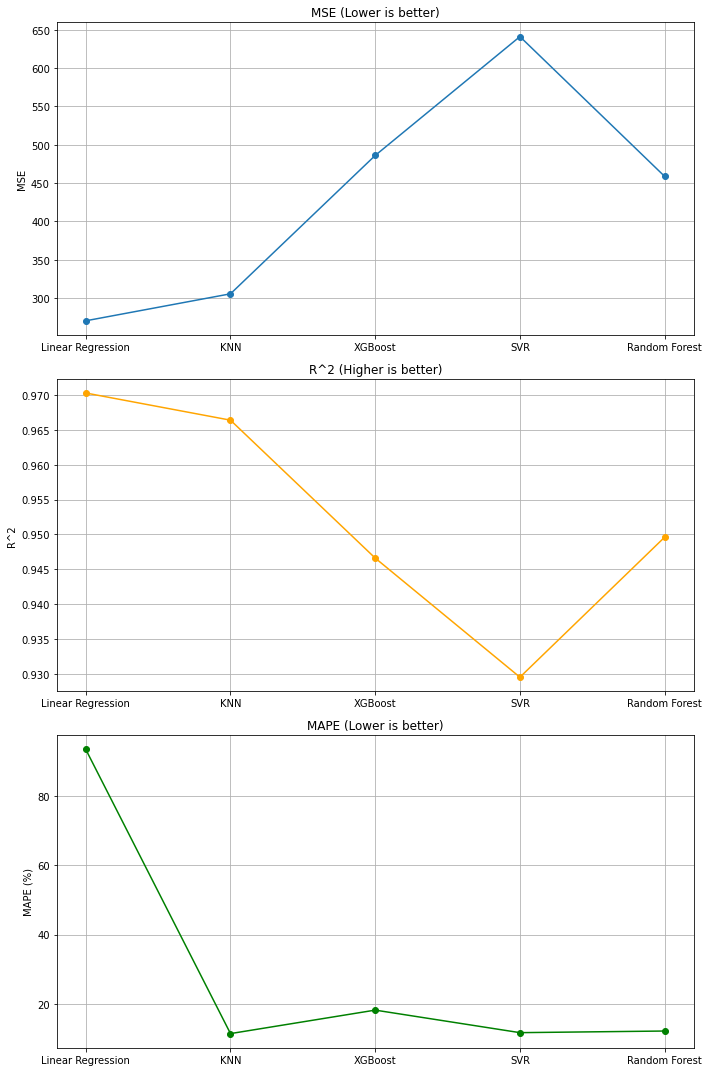

In [57]:
import matplotlib.pyplot as plt

# Data from the user's models
models = ['Linear Regression', 'KNN', 'XGBoost', 'SVR', 'Random Forest']
mse = [270.41, 305.61, 486.11, 641.16, 458.81]
r2 = [0.9703, 0.9664, 0.9466, 0.9295, 0.9496]
mape = [93.42, 11.47, 18.24, 11.74, 12.21]

# Create subplots: each metric will have its own subplot
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot MSE
ax[0].plot(models, mse, marker='o', linestyle='-')
ax[0].set_title('MSE (Lower is better)')
ax[0].set_ylabel('MSE')
ax[0].grid(True)

# Plot R^2
ax[1].plot(models, r2, marker='o', color='orange', linestyle='-')
ax[1].set_title('R^2 (Higher is better)')
ax[1].set_ylabel('R^2')
ax[1].grid(True)

# Plot MAPE
ax[2].plot(models, mape, marker='o', color='green', linestyle='-')
ax[2].set_title('MAPE (Lower is better)')
ax[2].set_ylabel('MAPE (%)')
ax[2].grid(True)

# Set the layout to be tight so the plots are closer to each other
plt.tight_layout()
plt.show()


In [58]:
# Assuming the necessary imports are already done and models are trained for Ethereum

def mape(y_true, y_pred): 
    """
    Calculate Mean Absolute Percentage Error
    """
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Replace linReg_Monero with linReg_Ethereum and adjust variable names for Ethereum
models = [linReg_Ethereum, knn_model, xgb_model, svr_model, rf_model]  # Make sure these are Ethereum models
model_names = ["Linear Regression", "KNN", "XGBoost", "SVR", "Random Forest"]

for model, name in zip(models, model_names):
    y_pred = model.predict(x_test_Ethereum.reshape(-1, 1))  # Reshape if necessary
    mse = mean_squared_error(y_test_Ethereum, y_pred)
    r2 = r2_score(y_test_Ethereum, y_pred)
    mape_value = mape(y_test_Ethereum, y_pred)
    print(f"Ethereum - {name} - MSE: {mse}, R^2: {r2}, MAPE: {mape_value}%")


Ethereum - Linear Regression - MSE: 11001.17019193956, R^2: 0.97205391550087, MAPE: 115.53432750311462%
Ethereum - KNN - MSE: 336707.904296806, R^2: 0.14466666901509406, MAPE: 21.680189534673644%
Ethereum - XGBoost - MSE: 332341.41861573403, R^2: 0.1557587779160986, MAPE: 22.425730693709593%
Ethereum - SVR - MSE: 414546.0381932268, R^2: -0.053064211352320756, MAPE: 28.381772752415714%
Ethereum - Random Forest - MSE: 335337.4016439517, R^2: 0.1481481334661221, MAPE: 23.035561553982753%


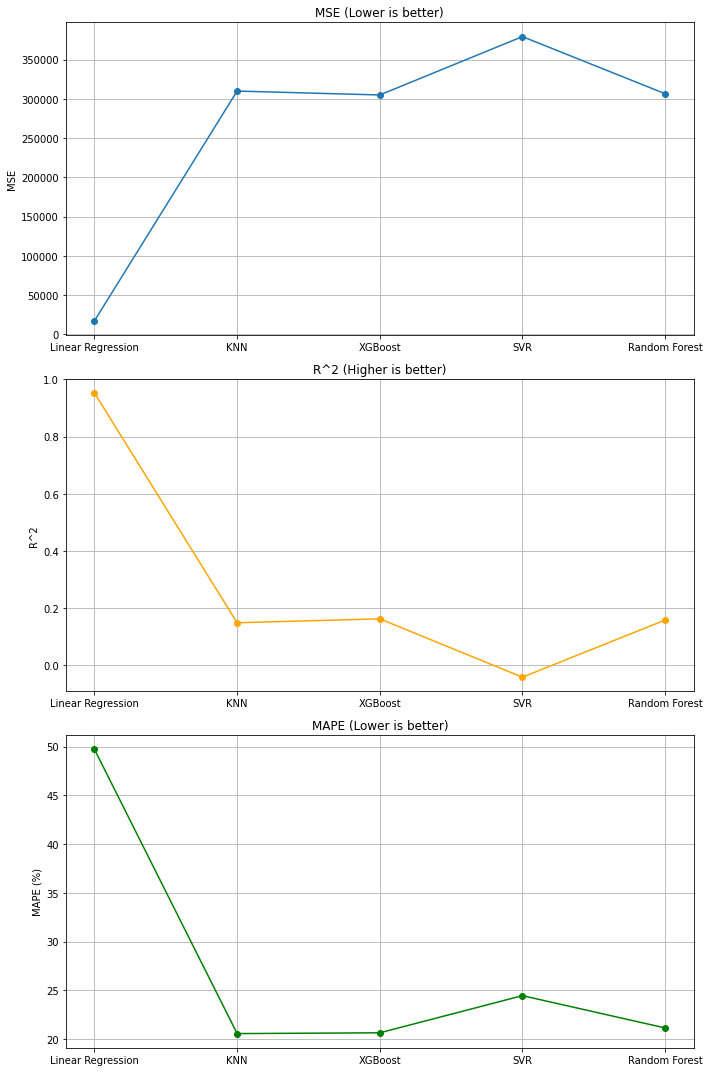

In [59]:
# Given data from the Ethereum model's evaluation
models = ['Linear Regression', 'KNN', 'XGBoost', 'SVR', 'Random Forest']
mse = [17283.21, 309951.37, 304957.69, 379308.11, 306587.32]
r2 = [0.9525, 0.1486, 0.1623, -0.0419, 0.1579]
mape = [49.71, 20.57, 20.65, 24.46, 21.15]

# Create subplots: each metric will have its own subplot
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot MSE
ax[0].plot(models, mse, marker='o', linestyle='-')
ax[0].set_title('MSE (Lower is better)')
ax[0].set_ylabel('MSE')
ax[0].grid(True)

# Plot R^2
ax[1].plot(models, r2, marker='o', color='orange', linestyle='-')
ax[1].set_title('R^2 (Higher is better)')
ax[1].set_ylabel('R^2')
ax[1].grid(True)

# Plot MAPE
ax[2].plot(models, mape, marker='o', color='green', linestyle='-')
ax[2].set_title('MAPE (Lower is better)')
ax[2].set_ylabel('MAPE (%)')
ax[2].grid(True)

# Set the layout to be tight so the plots are closer to each other
plt.tight_layout()
plt.show()


In [60]:
def mape(y_true, y_pred): 
    """
    Calculate Mean Absolute Percentage Error
    """
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Replace linReg_Ethereum with linReg_WrappedBitcoin and adjust variable names for WrappedBitcoin
models = [linReg_WrappedBitcoin, knn_model, xgb_model, svr_model, rf_model]  # These should be your Wrapped Bitcoin models
model_names = ["Linear Regression", "KNN", "XGBoost", "SVR", "Random Forest"]

for model, name in zip(models, model_names):
    y_pred = model.predict(x_test_WrappedBitcoin.reshape(-1, 1))  # Reshape if necessary
    mse = mean_squared_error(y_test_WrappedBitcoin, y_pred)
    r2 = r2_score(y_test_WrappedBitcoin, y_pred)
    mape_value = mape(y_test_WrappedBitcoin, y_pred)
    print(f"Wrapped Bitcoin - {name} - MSE: {mse}, R^2: {r2}, MAPE: {mape_value}%")


Wrapped Bitcoin - Linear Regression - MSE: 5294091.595953214, R^2: 0.9788083848550235, MAPE: 7.085681114913866%
Wrapped Bitcoin - KNN - MSE: 506215148.6575575, R^2: -1.0263186642082478, MAPE: 95.8166318683548%
Wrapped Bitcoin - XGBoost - MSE: 505841032.91636467, R^2: -1.0248211236645415, MAPE: 95.69136714106494%
Wrapped Bitcoin - SVR - MSE: 511989447.5326297, R^2: -1.0494324916278823, MAPE: 97.73856716291661%
Wrapped Bitcoin - Random Forest - MSE: 506081477.3003267, R^2: -1.0257835937609387, MAPE: 95.77188534701395%


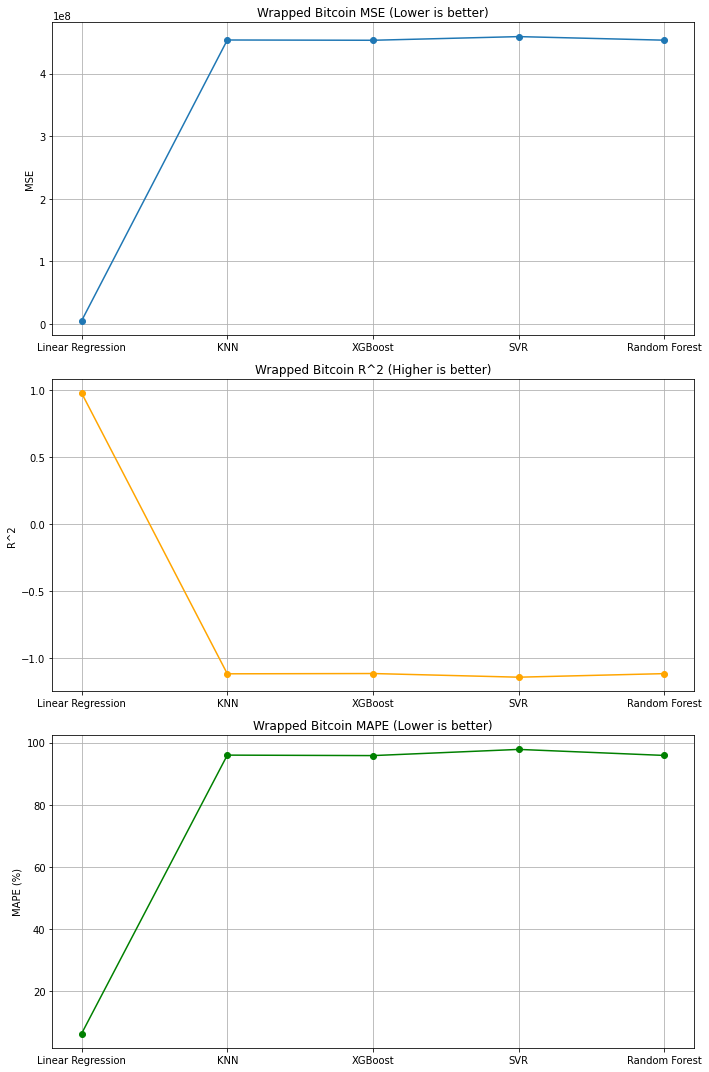

In [61]:
# Data from the Wrapped Bitcoin model's evaluation
models_wrapped_bitcoin = ['Linear Regression', 'KNN', 'XGBoost', 'SVR', 'Random Forest']
mse_wrapped_bitcoin = [5071654.92, 453842304.67, 453396311.67, 459248355.31, 453535785.44]
r2_wrapped_bitcoin = [0.9763, -1.1189, -1.1168, -1.1441, -1.1175]
mape_wrapped_bitcoin = [6.34, 95.98, 95.83, 97.82, 95.88]

# Create subplots: each metric will have its own subplot for Wrapped Bitcoin
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot MSE for Wrapped Bitcoin
ax[0].plot(models_wrapped_bitcoin, mse_wrapped_bitcoin, marker='o', linestyle='-')
ax[0].set_title('Wrapped Bitcoin MSE (Lower is better)')
ax[0].set_ylabel('MSE')
ax[0].grid(True)

# Plot R^2 for Wrapped Bitcoin
ax[1].plot(models_wrapped_bitcoin, r2_wrapped_bitcoin, marker='o', color='orange', linestyle='-')
ax[1].set_title('Wrapped Bitcoin R^2 (Higher is better)')
ax[1].set_ylabel('R^2')
ax[1].grid(True)

# Plot MAPE for Wrapped Bitcoin
ax[2].plot(models_wrapped_bitcoin, mape_wrapped_bitcoin, marker='o', color='green', linestyle='-')
ax[2].set_title('Wrapped Bitcoin MAPE (Lower is better)')
ax[2].set_ylabel('MAPE (%)')
ax[2].grid(True)

# Set the layout to be tight so the plots are closer to each other
plt.tight_layout()
plt.show()


In [62]:
def mape(y_true, y_pred): 
    """
    Calculate Mean Absolute Percentage Error
    """
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Replace linReg_Ethereum with linReg_Bitcoin and adjust variable names for Bitcoin
models = [linReg_Bitcoin, knn_model, xgb_model, svr_model, rf_model]  # These should be your Bitcoin models
model_names = ["Linear Regression", "KNN", "XGBoost", "SVR", "Random Forest"]

for model, name in zip(models, model_names):
    y_pred = model.predict(x_test_Bitcoin.reshape(-1, 1))  # Reshape if necessary
    mse = mean_squared_error(y_test_Bitcoin, y_pred)
    r2 = r2_score(y_test_Bitcoin, y_pred)
    mape_value = mape(y_test_Bitcoin, y_pred)
    print(f"Bitcoin - {name} - MSE: {mse}, R^2: {r2}, MAPE: {mape_value}%")


Bitcoin - Linear Regression - MSE: 1185061.3663923189, R^2: 0.9875754377300202, MAPE: 14.907533965268144%
Bitcoin - KNN - MSE: 126107030.37737538, R^2: -0.3221464272148302, MAPE: 58.67286206991154%
Bitcoin - XGBoost - MSE: 125976987.34852841, R^2: -0.32078301452118674, MAPE: 58.259263452855805%
Bitcoin - SVR - MSE: 128127974.54906283, R^2: -0.3433346520758971, MAPE: 66.98311825835084%
Bitcoin - Random Forest - MSE: 126060686.33397292, R^2: -0.3216605414460203, MAPE: 59.03309609936359%


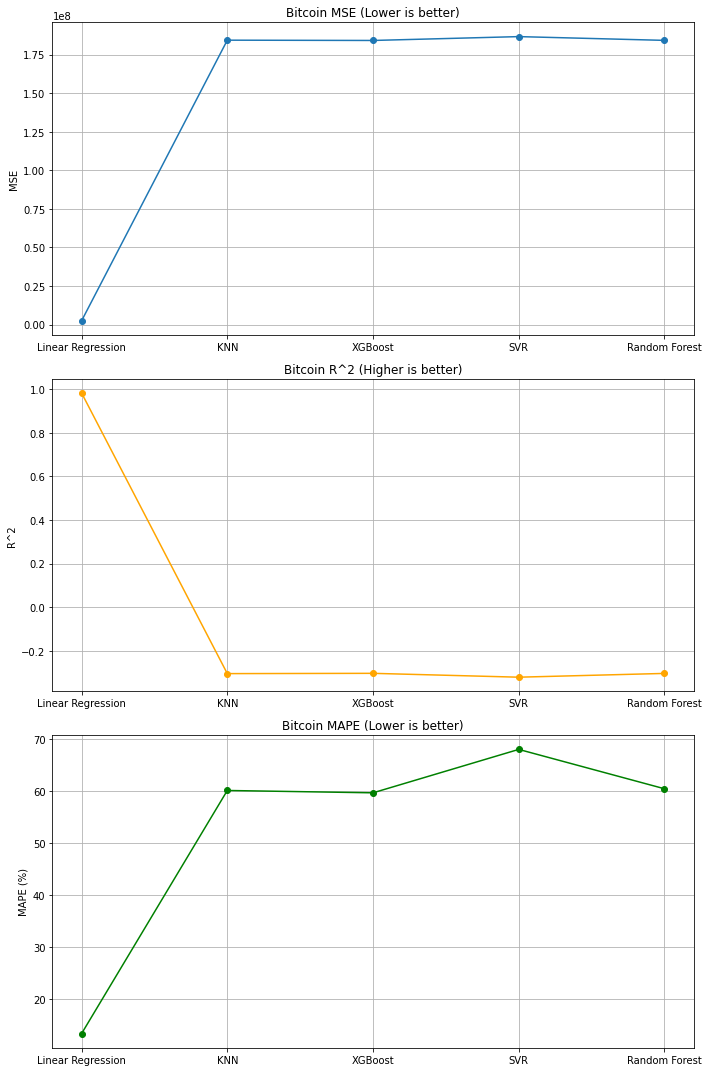

In [63]:
# Data from the Bitcoin model's evaluation
models_bitcoin = ['Linear Regression', 'KNN', 'XGBoost', 'SVR', 'Random Forest']
mse_bitcoin = [2428490.96, 184387425.96, 184197843.73, 186697718.20, 184257251.30]
r2_bitcoin = [0.9828, -0.3042, -0.3029, -0.3206, -0.3033]
mape_bitcoin = [13.42, 60.13, 59.68, 68.02, 60.46]

# Create subplots: each metric will have its own subplot for Bitcoin
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot MSE for Bitcoin
ax[0].plot(models_bitcoin, mse_bitcoin, marker='o', linestyle='-')
ax[0].set_title('Bitcoin MSE (Lower is better)')
ax[0].set_ylabel('MSE')
ax[0].grid(True)

# Plot R^2 for Bitcoin
ax[1].plot(models_bitcoin, r2_bitcoin, marker='o', color='orange', linestyle='-')
ax[1].set_title('Bitcoin R^2 (Higher is better)')
ax[1].set_ylabel('R^2')
ax[1].grid(True)

# Plot MAPE for Bitcoin
ax[2].plot(models_bitcoin, mape_bitcoin, marker='o', color='green', linestyle='-')
ax[2].set_title('Bitcoin MAPE (Lower is better)')
ax[2].set_ylabel('MAPE (%)')
ax[2].grid(True)

# Set the layout to be tight so the plots are closer to each other
plt.tight_layout()
plt.show()
